# 1. Environment & Paths
라이브러리, 데이터 경로, 학습 설정값을 준비
출력물 저장 위치와 checkpoint 관련 옵션도 여기서 함께 관리


In [2]:
# BERT pretrain 노트북 전체에서 공통으로 사용할 라이브러리와 경로를 한 번에 준비합니다.
# 이후 셀들은 이 설정을 전제로 동작하므로, 데이터 위치, 결과 저장 위치, 재현 가능한 랜덤 시드가
# 여기서 먼저 고정되어야 나중에 tokenizer, 데이터셋, 모델, 학습 결과가 일관되게 연결됩니다.
# 특히 checkpoint 기능을 안정화하면서 저장 경로와 재개할 파일 경로를 초반에 명확히 두는 것이 중요합니다.
from __future__ import absolute_import, division, print_function, unicode_literals

import copy
import json
import math
import os
import random
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
WORK_DIR = BASE_DIR / "work"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
WORK_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

corpus_file = DATA_DIR / "kowiki.txt"
sp_model_path = DATA_DIR / "ko_32000.model"
sp_vocab_path = DATA_DIR / "ko_32000.vocab"
pretrain_json_path = WORK_DIR / "bert_pre_train.json"
checkpoint_dir = CHECKPOINT_DIR
load_checkpoint_path = None
save_checkpoint_every_epoch = True
save_weights_only_every_epoch = True
checkpoint_verbose = True
show_sample_outputs = True
dataset_count = 16000
batch_size = 8

# 2. Tokenizer
SentencePiece tokenizer를 로드하고, MLM에서 random replacement에 사용할 일반 vocab 목록을 생성

필요하면 sample tokenization도 간단히 확인

In [3]:
# SentencePiece tokenizer를 실제 학습에 투입하기 전에 로드하고, random token 치환에 사용할 vocab 목록을 만듭니다.
# BERT의 MLM은 일부 토큰을 [MASK], random token, original token으로 바꿔가며 학습하므로,
# 여기서 만든 vocab_list는 나중에 10% random replacement를 구현할 때 직접 사용됩니다.
# 또한 특수 토큰은 random replacement 후보에 넣지 않는 것이 일반적이므로 별도로 제외합니다.
vocab = spm.SentencePieceProcessor()
vocab.load(str(sp_model_path))

vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

if show_sample_outputs:
    sample_text = "추적추적 비가 내리는 날이었어"
    print(f"vocab size: {len(vocab)}")
    print(f"sample tokenization: {vocab.encode_as_pieces(sample_text)}")


vocab size: 32007
sample tokenization: ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어']


# 3. Pretrain Data Generation
MLM/NSP용 instance를 만들고, JSON lines와 memmap 포맷으로 학습 데이터를 준비

중간 샘플을 한두 개만 보여줘서 전처리 결과를 빠르게 확인


In [4]:
# BERT pretrain용 데이터를 만드는 핵심 전처리 함수를 모아 둡니다.
# 이 단계에서는 "원시 문장 -> MLM/NSP 학습 예제 -> JSON 저장 -> memmap 로드" 흐름을 완성합니다.
# BERT는 한 번에 MLM과 NSP를 같이 학습하므로, 각 instance 안에는 token sequence, segment 정보,
# is_next label, 그리고 MLM 정답 위치(mask_idx/mask_label)가 함께 들어 있어야 합니다.
# 아래 함수들은 그 조합을 만드는 역할을 순서대로 담당합니다.

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # BERT의 MLM은 subword를 무작위로 찢어 가리는 것보다, 같은 단어에 속한 조각들을 같이 다루는 편이
    # 더 자연스러운 학습 신호를 주는 경우가 많습니다. SentencePiece에서는 공백 경계가 "▁"로 표시되므로,
    # 여기서는 공백 기준으로 이어진 subword들을 한 묶음 후보(cand_idx)로 만듭니다.
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith("▁"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)

    # BERT 논문에서 사용하는 80/10/10 규칙을 그대로 따릅니다.
    # 선택된 위치의 80%는 [MASK], 10%는 random token, 10%는 원래 token 유지입니다.
    # 이렇게 해야 모델이 [MASK] 토큰에만 과도하게 의존하지 않고 실제 입력 분포와도 어느 정도 맞닿게 됩니다.
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)

            # mask_idx와 mask_label은 나중에 MLM loss를 계산할 때 "어느 위치를 맞혀야 하는지"를 알려주는 정답입니다.
            # 즉 입력 sequence는 바뀌더라도, label 쪽에는 원래 token id가 남아 있어야 복원 학습이 가능합니다.
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label


def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    # BERT 입력은 [CLS], [SEP], [SEP]까지 포함해야 하므로 실제 문장 토큰 길이는 max_seq를 넘지 않아야 합니다.
    # 너무 길어진 경우 더 긴 쪽을 줄여 두 문장을 함께 시퀀스 안에 넣습니다.
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # BERT는 [CLS] + sentence A + [SEP] + sentence B + [SEP] 구조를 사용하므로,
    # 실제 문장 토큰이 사용할 수 있는 최대 길이는 n_seq - 3 입니다.
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        # 문서를 line 단위로 읽다가 충분히 길어졌거나 마지막 줄에 도달하면 하나의 pretrain instance를 만듭니다.
        # 이렇게 하면 긴 문서를 여러 instance로 자연스럽게 나눌 수 있고, NSP용 문장 쌍도 같은 문서 안에서 구성할 수 있습니다.
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # NSP는 두 문장이 실제로 이어지는지 판별하는 task입니다.
            # 여기서는 50% 확률로 문장 순서를 뒤집어 false example을 만들고, 그렇지 않으면 true example으로 둡니다.
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            if len(tokens_a) == 0 or len(tokens_b) == 0:
                current_chunk = []
                current_length = 0
                continue

            # [CLS]는 문장 쌍 전체를 대표하는 위치로 사용되고, [SEP]는 두 문장의 경계를 모델에게 알려줍니다.
            # segment는 sentence A 영역은 0, sentence B 영역은 1로 채워서 두 문장을 구분하도록 돕습니다.
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens,
                max(1, int((len(tokens) - 3) * mask_prob)),
                vocab_list,
            )

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances


def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """pretrain 데이터 생성"""

    # JSON line 포맷으로 먼저 저장해 두면, 대용량 코퍼스를 한 번에 메모리에 올리지 않고도
    # 이후 단계에서 필요한 만큼만 다시 읽을 수 있습니다. 즉 "생성 단계"와 "학습 적재 단계"를 분리하는 구조입니다.
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    out_file.parent.mkdir(parents=True, exist_ok=True)
    with open(in_file, "r", encoding="utf-8") as in_f:
        with open(out_file, "w", encoding="utf-8") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="make_pretrain_data"):
                line = line.strip()
                if line == "":
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)

            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)


def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    filename = Path(filename)

    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and total >= count:
                break

    memmap_dir = WORK_DIR / filename.stem
    memmap_dir.mkdir(parents=True, exist_ok=True)

    enc_tokens = np.memmap(memmap_dir / "enc_tokens.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(memmap_dir / "segments.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(memmap_dir / "labels_nsp.memmap", mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(memmap_dir / "labels_mlm.memmap", mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="load_pre_train_data")):
            if i >= total:
                break

            data = json.loads(line)
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))

            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            label_nsp = data["is_next"]
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


def read_sample_doc(in_file, n_lines=4):
    sample_doc = []
    with open(in_file, "r", encoding="utf-8") as in_f:
        for line in in_f:
            line = line.strip()
            if not line:
                if sample_doc:
                    break
                continue
            sample_doc.append(vocab.encode_as_pieces(line))
            if len(sample_doc) >= n_lines:
                break
    return sample_doc


In [6]:
# 실제 전처리 결과가 어떻게 생기는지 최소한으로 확인합니다.
# 너무 많은 샘플을 찍으면 노트북이 지저분해지므로, 대표 instance 하나만 요약해서 보여줍니다.
if show_sample_outputs:
    sample_doc = read_sample_doc(corpus_file, n_lines=4)
    sample_n_seq = config.n_seq if "config" in globals() else 128
    sample_instances = create_pretrain_instances(vocab, sample_doc, sample_n_seq, 0.15, vocab_list)
    if sample_instances:
        sample_instance = sample_instances[0]
        print("sample instance summary")
        print(f"tokens[:20]: {sample_instance['tokens'][:20]}")
        print(f"segment[:20]: {sample_instance['segment'][:20]}")
        print(f"is_next: {sample_instance['is_next']}")
        print(f"mask_idx[:10]: {sample_instance['mask_idx'][:10]}")
        print(f"mask_label[:10]: {sample_instance['mask_label'][:10]}")


sample instance summary
tokens[:20]: ['[CLS]', '▁"', '땅', '콩', '▁농부', '"', '▁(', 'P', 'ean', 'ut', '▁F', 'ar', 'mer', ')', '로', '▁알려졌다', '.', '▁1962', '년', '▁조지아']
segment[:20]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
is_next: 0
mask_idx[:10]: [10, 11, 12, 13, 14, 36, 37, 38, 49, 50]
mask_label[:10]: ['▁F', 'ar', 'mer', ')', '로', '▁당선', '되고', ',', '▁조지아', '▁주']


# 4. Transformer Utilities
BERT 구현 전에 masking, activation, config 같은 공통 유틸리티를 먼저 정의

In [9]:
# Transformer/BERT 구현에 자주 반복해서 쓰이는 유틸리티 함수들을 먼저 정의합니다.
# pad mask는 attention이 실제 토큰이 아닌 padding 위치를 보지 않도록 만들고,
# ahead mask는 decoder 계열에서 미래 정보를 가릴 때 쓰는 기본 도구입니다.
# BERT는 encoder-only 구조라 실제 학습에서는 pad mask 중심으로 사용되지만,
# ahead mask를 같이 두면 Transformer 계열 마스킹 개념을 함께 이해하기 좋습니다.

def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, "r", encoding="utf-8") as f:
            config = json.loads(f.read())
            return Config(config)


# 5. BERT Model
이 구간은 embedding, attention, encoder layer, pretrain head를 포함한 mini BERT 본체

최종적으로 `[CLS]` 표현은 NSP에, token-level hidden state는 MLM에 연결


In [10]:
# BERT 본체와 pretrain head를 구성하는 모델 클래스를 정의합니다.
# 입력 token은 shared embedding, position embedding, segment embedding을 거쳐 encoder layers를 통과하고,
# 마지막에는 [CLS] 위치 표현으로 NSP를, 각 token 위치의 hidden state로 MLM을 동시에 예측합니다.
# 즉 이 셀은 "BERT가 어떻게 두 pretrain task를 한 몸체에서 함께 수행하는지"를 코드로 보여주는 부분입니다.

class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        if mode == "linear":
            return self._linear(inputs)
        raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)
        return outputs


class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position = torch.arange(inputs.size(1), device=inputs.device).unsqueeze(0).expand_as(inputs)
        embed = self.embedding(position)
        return embed


class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        attn_scale = attn_score / math.sqrt(K.size(-1))
        attn_scale = attn_scale.masked_fill(attn_mask.bool(), -1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]

        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out)
        return attn_out


class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        return enc_out


class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)


In [11]:
# mini BERT의 기본 크기를 한 곳에서 관리합니다.
# vocab 크기는 tokenizer와 반드시 맞아야 하므로 SentencePiece에서 읽은 실제 vocab 크기를 사용하고,
# padding id도 tokenizer 기준으로 맞춰야 마스크 계산과 loss 계산이 일관됩니다.
config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 128,
    "n_vocab": len(vocab),
    "i_pad": vocab.pad_id(),
})


# 6. Training Utilities
학습용 loss, accuracy, scheduler와 checkpoint 저장 유틸을 정의

checkpoint는 중간 실패에 덜 취약하도록 임시 파일을 거쳐 저장


In [12]:
# NSP/MLM 손실, 정확도, learning rate scheduler, 안전한 checkpoint 저장 함수를 정의합니다.
# 여기서 특히 중요한 점은 모델 출력에 softmax를 미리 적용하지 않는다는 것입니다.
# PyTorch의 CrossEntropyLoss는 내부적으로 log-softmax를 포함하므로, logits를 그대로 넣는 것이 올바른 학습 방식입니다.
# 또한 MLM은 sequence 전체를 다 맞히는 task가 아니라 "가려진 위치만" 맞히는 task이므로,
# loss와 accuracy 모두 비마스크 위치를 무시해야 합니다.

def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction="none")
    mask = (y_true != 0).float().view(-1)
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1)


def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != 0)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1).float()
    return accuracy


class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr
        return lr


def safe_torch_save(obj, path):
    # torch.save 중간 실패가 나면 파일이 깨진 상태로 남을 수 있으므로,
    # 같은 디렉터리에 임시 파일을 먼저 만든 뒤 저장이 성공하면 최종 이름으로 교체합니다.
    # 이렇게 하면 checkpoint 저장 오류가 나더라도 기존 정상 파일을 덮어쓰는 위험을 줄일 수 있습니다.
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp_name = tempfile.mkstemp(prefix=path.stem + "_", suffix=".tmp", dir=path.parent)
    os.close(fd)
    tmp_path = Path(tmp_name)

    try:
        torch.save(obj, tmp_path)
        os.replace(tmp_path, path)
        return True, f"saved: {path.name}"
    except Exception as error:
        if tmp_path.exists():
            tmp_path.unlink()
        return False, f"failed: {path.name} ({error})"


# 7. Dataset Loading
전처리된 JSON을 memmap 기반 배열로 불러오고, 실제 학습에 사용할 데이터셋 크기를 지정

샘플 출력은 한두 줄만 남겨서 결과를 빠르게 확인


In [13]:
# pretrain용 JSON 데이터를 생성하고, 실제 학습에 사용할 배열 형태로 로드합니다.
# 코퍼스 전체를 매번 즉시 tensor로 만들기보다, 한 번 JSON/memmap 형태로 정리해 두면
# 이후 학습 실험을 반복할 때 재사용하기 쉬워집니다. 즉 이 셀은 "원시 코퍼스에서 학습 가능한 배열"로 넘어가는 다리 역할입니다.
if not pretrain_json_path.exists():
    make_pretrain_data(vocab, corpus_file, pretrain_json_path, config.n_seq)

pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, config.n_seq, count=dataset_count)

print(f"dataset_count: {len(pre_train_labels[0])}")
print(f"n_seq: {config.n_seq}")
print(f"batch_size: {batch_size}")


load_pre_train_data:   0%|          | 0/16000 [00:00<?, ?it/s]

dataset_count: 16000
n_seq: 128
batch_size: 8


# 8. Training Setup
memmap을 배치 단위로 읽는 Dataset을 만들고, DataLoader / 모델 / optimizer / scheduler를 초기화

첫 batch shape를 미리 확인해서 학습 전에 입력 구성이 맞는지 sanity check


In [14]:
# 학습에 필요한 실행 객체를 모두 준비합니다.
# 여기서는 memmap 기반 Dataset 생성, DataLoader 준비, 모델/optimizer/scheduler 초기화, history 구조 준비,
# 그리고 checkpoint를 불러와 이어서 학습할 수 있는 resume 로직까지 한 번에 정리합니다.
# checkpoint는 단순히 가중치만 저장하는 것이 아니라, optimizer와 scheduler 상태,
# history, 현재 epoch까지 함께 저장해야 같은 지점에서 자연스럽게 이어서 학습할 수 있습니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PreTrainDataset(Dataset):
    # memmap 전체를 torch.tensor로 한 번에 바꾸면 데이터셋 자체가 큰 메모리를 차지합니다.
    # 그래서 여기서는 한 샘플을 꺼낼 때만 tensor로 변환해 DataLoader가 batch를 만들도록 구성합니다.
    # 이렇게 하면 학습 중 필요한 배치만 메모리에 올라오므로 메모리 압박이 훨씬 줄어듭니다.
    def __init__(self, inputs, labels):
        self.enc_tokens = inputs[0]
        self.segments = inputs[1]
        self.labels_nsp = labels[0]
        self.labels_mlm = labels[1]

    def __len__(self):
        return len(self.labels_nsp)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.enc_tokens[idx], dtype=torch.long),
            torch.tensor(self.segments[idx], dtype=torch.long),
            torch.tensor(self.labels_nsp[idx], dtype=torch.long),
            torch.tensor(self.labels_mlm[idx], dtype=torch.long),
        )

train_dataset = PreTrainDataset(pre_train_inputs, pre_train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model = build_model_pre_train(config).to(device)

epochs = 10
train_steps = math.ceil(len(train_dataset) / train_dataloader.batch_size) * epochs
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=1e-4,
)
loss_fn_nsp = nn.CrossEntropyLoss()

history = {
    "total_loss": [],
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
    "lr": [],
}
start_epoch = 0

if load_checkpoint_path is not None:
    checkpoint = torch.load(load_checkpoint_path, map_location=device)
    pre_train_model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    learning_rate_scheduler.step_num = checkpoint.get("scheduler_step_num", 0)
    history = checkpoint.get("history", history)
    start_epoch = checkpoint["epoch"] + 1

print(f"checkpoint dir: {checkpoint_dir}")
print(f"dataset length: {len(train_dataset)}")

sample_batch = next(iter(train_dataloader))
print(
    "first batch shapes:",
    tuple(sample_batch[0].shape),
    tuple(sample_batch[1].shape),
    tuple(sample_batch[2].shape),
    tuple(sample_batch[3].shape),
)


checkpoint dir: /home/jovyan/work/From_local/MiniBert/work/checkpoints
dataset length: 16000
first batch shapes: (8, 128) (8, 128) (8,) (8, 128)


# 9. Training Loop & Checkpoints
학습은 epoch 단위 로그만 출력해서 너무 시끄럽지 않게 유지

각 epoch이 끝나면 resume용 checkpoint와 weight-only 파일을 안전 저장 방식으로 기록


In [15]:
# 실제 pretrain 학습을 수행하고, epoch마다 checkpoint와 weight 파일을 저장합니다.
# 학습 루프 안에서는 batch 이동 -> forward -> loss 계산 -> backward -> optimizer step ->
# scheduler step -> metric 누적 순서가 반복됩니다.
# checkpoint를 epoch 단위로 남겨 두면 장시간 학습이 중단되어도 이어서 재개할 수 있고,
# 서로 다른 epoch 결과를 비교하거나 제출용 가중치를 따로 보관하기도 쉬워집니다.
for epoch in range(start_epoch, epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0
    current_lr = optimizer.param_groups[0]["lr"]

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = [tensor.to(device) for tensor in batch]

        optimizer.zero_grad()
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)
        total_loss_batch = loss_nsp + loss_mlm

        total_loss_batch.backward()
        optimizer.step()
        current_lr = learning_rate_scheduler.step()

        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc += (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean().item()
        total_mlm_acc += lm_acc(labels_mlm_batch, logits_mlm).item()

    num_batches = len(train_dataloader)
    avg_total_loss = total_loss / num_batches
    avg_nsp_loss = total_nsp_loss / num_batches
    avg_mlm_loss = total_mlm_loss / num_batches
    avg_nsp_acc = total_nsp_acc / num_batches
    avg_mlm_acc = total_mlm_acc / num_batches

    history["total_loss"].append(avg_total_loss)
    history["nsp_loss"].append(avg_nsp_loss)
    history["mlm_loss"].append(avg_mlm_loss)
    history["nsp_acc"].append(avg_nsp_acc)
    history["mlm_acc"].append(avg_mlm_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Total Loss: {avg_total_loss:.4f} | "
        f"NSP Loss: {avg_nsp_loss:.4f} | "
        f"MLM Loss: {avg_mlm_loss:.4f} | "
        f"NSP Acc: {avg_nsp_acc:.4f} | "
        f"MLM Acc: {avg_mlm_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if save_checkpoint_every_epoch:
        checkpoint_path = checkpoint_dir / f"bert_pre_train_checkpoint_epoch_{epoch + 1}.pt"
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": pre_train_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_step_num": learning_rate_scheduler.step_num,
            "history": history,
            "config": dict(config),
            "epochs": epochs,
            "batch_size": train_dataloader.batch_size,
            "pretrain_json_path": str(pretrain_json_path),
            "dataset_count": dataset_count,
        }
        success, message = safe_torch_save(checkpoint, checkpoint_path)
        if checkpoint_verbose:
            print(f"checkpoint: {message}")

    if save_weights_only_every_epoch:
        weights_path = checkpoint_dir / f"bert_pre_train_weights_epoch_{epoch + 1}.pt"
        success, message = safe_torch_save(pre_train_model.state_dict(), weights_path)
        if checkpoint_verbose:
            print(f"weights: {message}")


Epoch 1/10 | Total Loss: 9.9998 | NSP Loss: 0.6630 | MLM Loss: 9.3368 | NSP Acc: 0.5697 | MLM Acc: 0.0320 | LR: 0.000100
checkpoint: saved: bert_pre_train_checkpoint_epoch_1.pt
weights: saved: bert_pre_train_weights_epoch_1.pt
Epoch 2/10 | Total Loss: 9.2534 | NSP Loss: 0.6515 | MLM Loss: 8.6019 | NSP Acc: 0.5798 | MLM Acc: 0.0362 | LR: 0.000097
checkpoint: saved: bert_pre_train_checkpoint_epoch_2.pt
weights: saved: bert_pre_train_weights_epoch_2.pt
Epoch 3/10 | Total Loss: 9.2083 | NSP Loss: 0.6450 | MLM Loss: 8.5632 | NSP Acc: 0.5798 | MLM Acc: 0.0360 | LR: 0.000088
checkpoint: saved: bert_pre_train_checkpoint_epoch_3.pt
weights: saved: bert_pre_train_weights_epoch_3.pt
Epoch 4/10 | Total Loss: 9.1586 | NSP Loss: 0.6360 | MLM Loss: 8.5226 | NSP Acc: 0.5724 | MLM Acc: 0.0360 | LR: 0.000075
checkpoint: saved: bert_pre_train_checkpoint_epoch_4.pt
weights: saved: bert_pre_train_weights_epoch_4.pt
Epoch 5/10 | Total Loss: 9.1167 | NSP Loss: 0.6275 | MLM Loss: 8.4892 | NSP Acc: 0.5726 | ML

# 10. Visualization
학습이 끝나면 epoch별 history를 사용해 loss와 accuracy를 시각화

작은 모델에서는 정확도보다 loss 추세를 먼저 보는 편이 학습 안정성을 판단하기 좋음


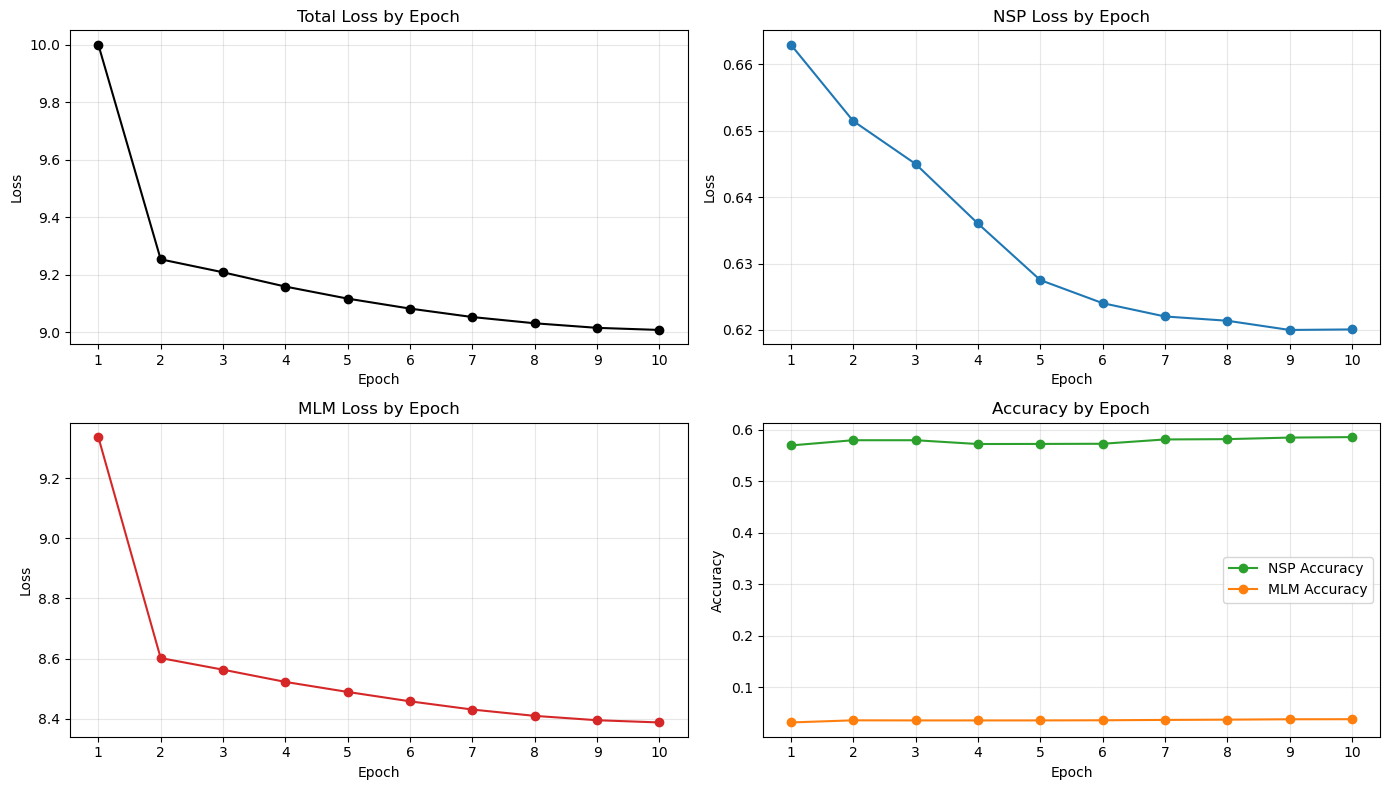

In [19]:
# 학습이 끝난 뒤 loss/accuracy 흐름을 시각화합니다.
# history가 비어 있으면 아직 학습을 돌리지 않았다는 뜻이므로, 불필요한 에러 대신 안내 메시지만 보여줍니다.
if len(history["total_loss"]) == 0:
    print("history가 비어 있습니다. 먼저 학습 셀을 실행하세요.")
else:
    epochs_range = range(1, len(history["total_loss"]) + 1)

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, history["total_loss"], marker="o", color="black")
    plt.title("Total Loss by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(list(epochs_range))
    plt.grid(alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, history["nsp_loss"], marker="o", color="tab:blue")
    plt.title("NSP Loss by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(list(epochs_range))
    plt.grid(alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.plot(epochs_range, history["mlm_loss"], marker="o", color="tab:red")
    plt.title("MLM Loss by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(list(epochs_range))
    plt.grid(alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(epochs_range, history["nsp_acc"], marker="o", label="NSP Accuracy", color="tab:green")
    plt.plot(epochs_range, history["mlm_acc"], marker="o", label="MLM Accuracy", color="tab:orange")
    plt.title("Accuracy by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(list(epochs_range))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()